In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd 
import base64
import os 
import sys 
import time 


In [3]:
root_dir= os.path.dirname(os.path.dirname(os.getcwd()))
sys.path.append(root_dir)
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.tools import tool
from langchain.agents import create_agent
from langchain.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver
from e2b_code_interpreter import Sandbox

In [5]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
checkpointer = InMemorySaver()
sbx = Sandbox.create(timeout=1*60)
response = sbx.run_code('print(5+8)')
response

Execution(Results: [], Logs: Logs(stdout: ['13\n'], stderr: []), Error: None)

In [6]:
response = sbx.run_code('print(0+8)')
response

Execution(Results: [], Logs: Logs(stdout: ['8\n'], stderr: []), Error: None)

In [7]:
import matplotlib.pyplot as plt 
import random

    Year  Car_Price_USD
0   2010          23336
1   2011          37736
2   2012          16718
3   2013          45324
4   2014          41215
5   2015          44628
6   2016          30020
7   2017          37607
8   2018          42424
9   2019          17171
10  2020          29273
11  2021          47488
12  2022          39261
13  2023          43810
14  2024          26249


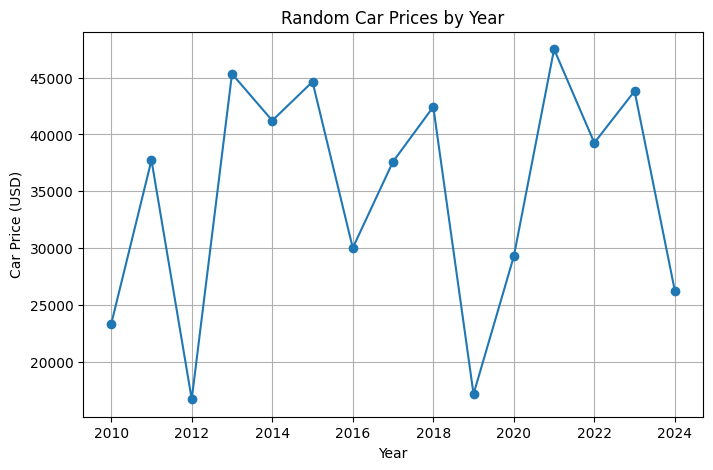

In [8]:
years = list(range(2010, 2025))

# Generate random car prices
prices = [random.randint(15000, 50000) for _ in years]

# Create pandas DataFrame
data = pd.DataFrame({
    "Year": years,
    "Car_Price_USD": prices
})

# Print dataset
print(data)

# Plot the data
plt.figure(figsize=(8,5))
plt.plot(data["Year"], data["Car_Price_USD"], marker="o")

plt.title("Random Car Prices by Year")
plt.xlabel("Year")
plt.ylabel("Car Price (USD)")
plt.grid(True)

plt.show()

In [9]:
code = '''
import pandas as pd
import matplotlib.pyplot as plt
import random
years = list(range(2010, 2025))

# Generate random car prices
prices = [random.randint(15000, 50000) for _ in years]

# Create pandas DataFrame
data = pd.DataFrame({
    "Year": years,
    "Car_Price_USD": prices
})

# Print dataset
print(data)

# Plot the data
plt.figure(figsize=(8,5))
plt.plot(data["Year"], data["Car_Price_USD"], marker="o")

plt.title("Random Car Prices by Year")
plt.xlabel("Year")
plt.ylabel("Car Price (USD)")
plt.grid(True)

plt.show()
'''

In [10]:
sbx = Sandbox.create(timeout=4*60)
response = sbx.run_code(code)
response

Execution(Results: [Result(<Figure size 800x500 with 1 Axes>)], Logs: Logs(stdout: ['    Year  Car_Price_USD\n0   2010          43142\n1   2011          31971\n2   2012          21321\n3   2013          26132\n4   2014          39300\n5   2015          49162\n6   2016          27186\n7   2017          42349\n8   2018          25567\n9   2019          40213\n10  2020          30821\n11  2021          45974\n12  2022          49590\n13  2023          40461\n14  2024          44827\n'], stderr: []), Error: None)

In [11]:
response.results[0].png

'...'

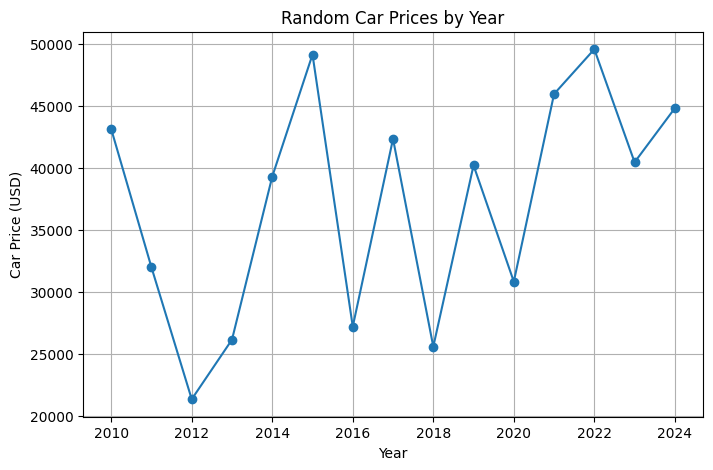

In [12]:
response.results[0]

In [13]:
def get_info(file_path):
   if file_path.endswith('.csv'):
        df = pd.read_csv(file_path, nrows = 3)
   else:
         df = pd.read_excel(file_path, nrows=3)

   return f"columns : {list(df.columns)} \n info : {df.to_string()}"


In [14]:
sbx = Sandbox.create(timeout=4*60)

In [15]:
@tool
def upload_file(filename = str):
    '''    
    Uploads a local file from ./data to the sandbox environment.
    Checks if the file exists locally and writes it to sandbox.
    Return'''
    filename = filename.lstrip('.').lstrip('/').lstrip('\\')
    file_path = f'../data/{filename}'
    if not os.path.exists(file_path):
        return f"Error: File not found {file_path}"
    with open(file_path, 'rb') as f :
        sandbox_file = sbx.files.write(f'/data/{file_path}',f)
        #info = get_info(sandbox_file)
    return f"File uploaded to sandbox  \nFile path {sandbox_file.path}"

In [16]:
upload_file.invoke("google_2024.xlsx")

'File uploaded to sandbox  \nFile path /data/../data/google_2024.xlsx'

In [17]:
get_info(file_path=r'F:\WORK\GENAI\ai-agents\Ai-Travel-Planner\data\apple_2024.xlsx')

"columns : ['APPLE INC. - FINANCIAL STATEMENTS 2024', 'Unnamed: 1'] \n info :   APPLE INC. - FINANCIAL STATEMENTS 2024   Unnamed: 1\n0                                    NaN          NaN\n1       BALANCE SHEET (as of 2024-09-30)          NaN\n2                                   Item  Value (USD)"

In [18]:
r = ['num', 'dfjkds']
p = "\n".join(r)
print(p)

num
dfjkds


## if any changes is made in any tool . then the create agent cell must be rerun

In [ ]:
@tool 
def run_code(code:str):
    '''
    executes python code in sandbox 
    
    args: 
     code : valid python code which is executable 

    returns:
     execution result  
    
    '''
    print("running sandbox code")

    execution = sbx.run_code(code)
    print("code execution done")

    if execution.error :
        return f"Error occured name : {execution.error.name} value : {execution.error.value}"
    
    os.makedirs('images', exist_ok=True)
    

    output = []
    timestamp = int(time.time()) # it gave error if variable name was time . there was a conflict 
    output.append(str(execution))
    
    for i,result in enumerate(execution.results):

      if result.png:
        file_name = f"images/{timestamp}_no_{i}.png" #.images makes it hidden . removed the . 

        with open (file_name, 'wb') as f :
           f.write(base64.b64decode(result.png))
           
        output.append (f"chart saved to {file_name}")

    return "\n".join(output) if output else "Code executed .No output was returned"    



In [20]:
root_dir = os.path.dirname(os.getcwd())
sys.path.append(root_dir)
print(root_dir)

f:\WORK\GENAI\ai-agents\Ai-Travel-Planner


In [37]:
load_dotenv()
from langchain_groq import ChatGroq
llm2 = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.7
)


# the create_agent cell must be reloaded if any changes is made in tools 

In [47]:
from scripts import prompts
from langchain.agents.middleware import FilesystemFileSearchMiddleware

agent = create_agent(

    model = llm2,
    system_prompt=prompts.CODE_EXECUTION_PROMPT,
    tools=[upload_file, run_code],
    middleware=[FilesystemFileSearchMiddleware(
        root_path='../data',
        use_ripgrep=True,
        max_file_size_mb=500
     )
    ]
) 


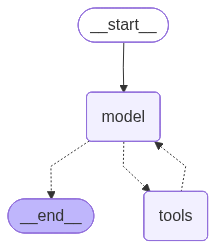

In [23]:
agent

In [24]:
import os
print(os.getenv("GROQ_API_KEY"))

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


In [39]:
sbx = Sandbox.create(timeout=4*60)

config = {"configurable": {"thread_id": "one"}}

query = "Analyze apple 2024 data and calculate financial ratios"

result = agent.invoke({"messages": [HumanMessage(content=query)]}, config=config)

running sandbox code
code execution done


In [49]:
sbx = Sandbox.create(timeout=4*60)
config = {"configurable": {"thread_id": "movie-1"}}

query = "Upload IMDB-Movie-Data.csv and create a line chart showing average ratings over years"

result = agent.invoke({'messages': [HumanMessage(query)]}, config=config)

running sandbox code
code execution done
running sandbox code
code execution done
running sandbox code
code execution done
running sandbox code
code execution done
running sandbox code
code execution done
running sandbox code
code execution done


In [34]:
query = """
From titanic.csv, group passengers by Sex and Survived, 
then create a grouped bar chart where the x-axis is Sex (male, female), 
the y-axis is passenger count, and bars are split by survival status (0 = died, 1 = survived). 
Include a legend and interpret the result.
"""

result = agent.invoke({"messages": [HumanMessage(content=query)]}, config=config)
print(result['messages'][-1].text)


running sandbox code
running sandbox code
running sandbox code
running sandbox code
running sandbox code
running sandbox code


RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01k94xwwf3exv8terdac21qbsp` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 100000, Requested 3039. Please try again in 43m45.696s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}